# Stratigraphic column

This notebook builds the D-6A stratigraphic column from the CSV files in this directory, using [pystrat](https://pystrat.readthedocs.io/) for the lithologic column. The plotting functions are imported from [`plot_D_6A.py`](plot_D_6A.py) so that the figure rendered here and the figure written by the command-line script are generated by the same code.

Alongside the lithology, the figure shows the depths of the samples collected in May 2026, the Exxon 1979 Cu-Ni-Co assays, and the KT-10 magnetic susceptibility profile measured on the split core.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start):
    """Return the repository root, identified as the directory holding myst.yml.

    Args:
        start (Path): Directory to begin searching from.

    Returns:
        Path: The repository root.
    """
    for candidate in [start, *start.parents]:
        if (candidate / 'myst.yml').exists():
            return candidate
    raise FileNotFoundError('could not locate the repository root (no myst.yml found)')


# Anchoring on the repository root keeps the notebook runnable whether it is
# executed from its own directory (JupyterLab) or from the root (book build).
repo = find_repo_root(Path.cwd().resolve())
log_dir = repo / 'D-6A_log'
sys.path.insert(0, str(log_dir))

import plot_D_6A as d6a

## Load the section, the samples, and the down-core data

The section is loaded at the primary-interval granularity (42 rows; Severson's intended unit granularity). Swap in `D_6A_section_detailed.csv` for the 137-row version that splits at every named lithologic sub-interval.

In [2]:
section, style, section_df = d6a.load_section(
    log_dir / 'D_6A_section_primary.csv',
    log_dir / 'D_6A_style.csv',
)
print(f'{section.n_beds} beds, {section.total_thickness:.0f} ft, '
      f'{section.n_unique_facies} unique facies')

samples_df = d6a.load_magnetics_samples(repo / 'D-6A_sampling' / 'D-6A_samples.csv')
print(f'{len(samples_df)} magnetics samples')

# Exxon 1979 assays. Below-detection values are stored as negatives in the CSV
# and are filtered out by attach_geochem.
geochem_csv = log_dir / 'D_6A_geochem_exxon.csv'
d6a.attach_geochem(section, {
    'Cu_pct': (geochem_csv, 'Cu_pct'),
    'Ni_ppm': (geochem_csv, 'Ni_ppm'),
    'Co_ppm': (geochem_csv, 'Co_ppm'),
})

susc_csv = repo / 'D-6A_data' / 'susceptibility_KT10' / 'D-6A_KT10_susceptibility.csv'
d6a.attach_susceptibility(section, susc_csv)

46 beds, 2125 ft, 18 unique facies
84 magnetics samples
  attached Cu_pct: 101 samples from D_6A_geochem_exxon.csv
  attached Ni_ppm: 101 samples from D_6A_geochem_exxon.csv
  attached Co_ppm: 45 samples from D_6A_geochem_exxon.csv
  attached susc: 623 measurements from D-6A_KT10_susceptibility.csv (depth 125-2125 ft)


## The D-6A section

/Users/unimos/0000_Github/2026_SSRM_Duluth_Complex/D-6A_log/plot_D_6A.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.945))


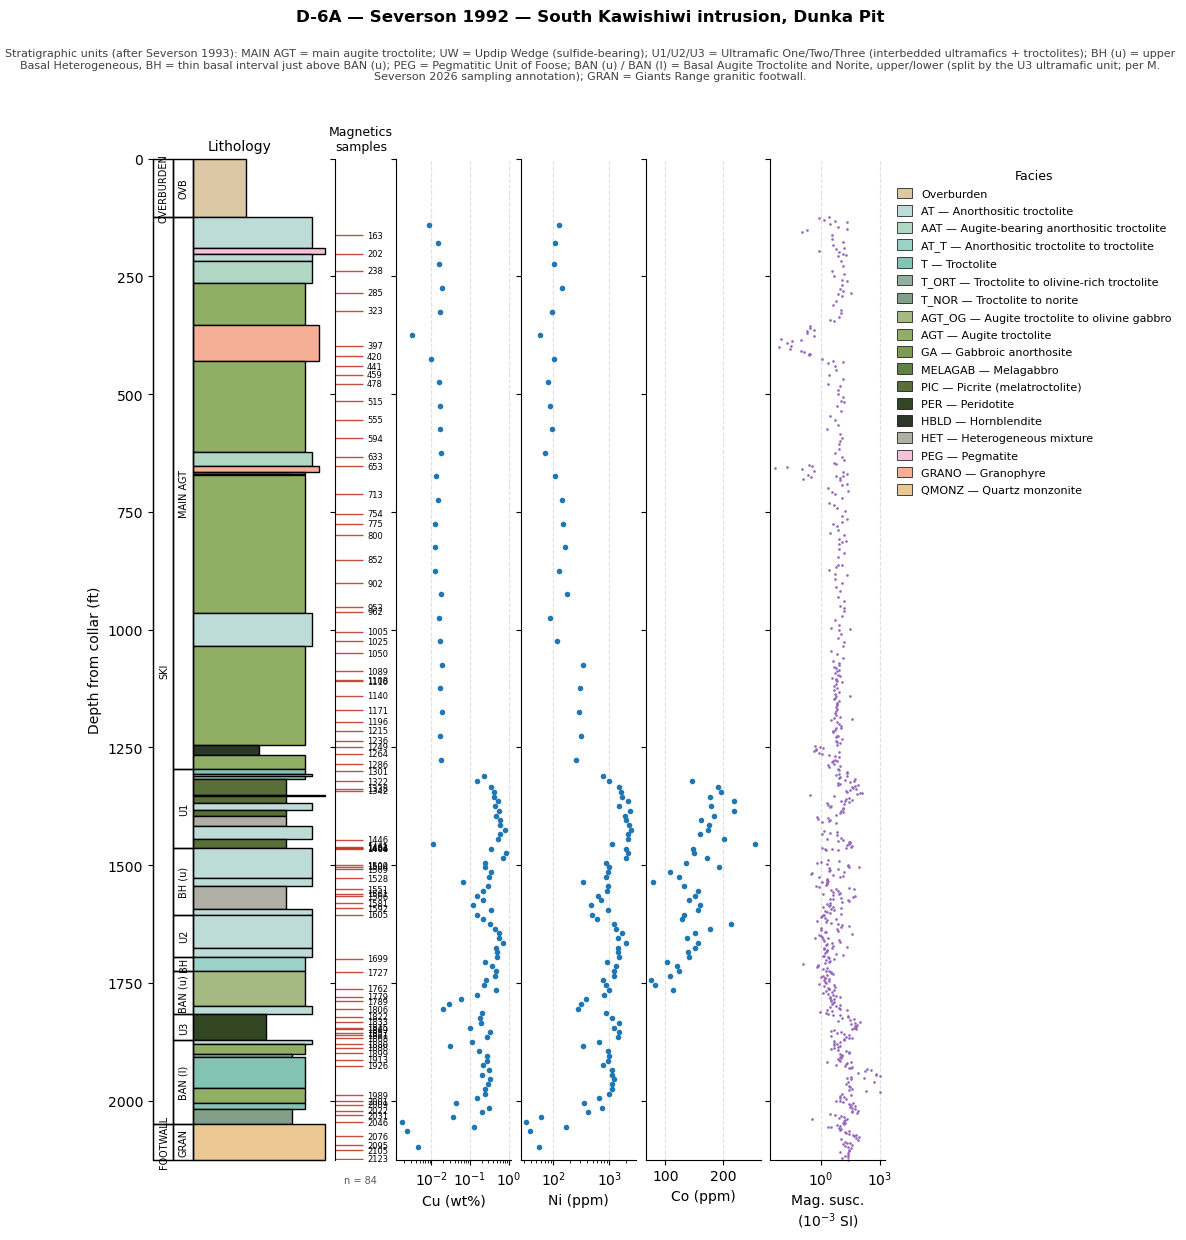

In [3]:
panels = [
    ('Cu_pct', 'Cu (wt%)', True, 'markers'),
    ('Ni_ppm', 'Ni (ppm)', True, 'markers'),
    ('Co_ppm', 'Co (ppm)', False, 'markers'),
    ('susc', 'Mag. susc.\n(10$^{-3}$ SI)', True, 'points'),
]

fig = d6a.plot_figure(section, style, panels, samples_df=samples_df)

## Magnetic susceptibility by facies

Each KT-10 measurement is assigned to a lithology by matching its depth against the detailed section intervals. The measurements were made in half-core mode on a roughly split (rather than sawn) surface, so the values carry the geometric caveats described in the [repository overview](../README.md) and should be treated as relative rather than absolute susceptibilities.

The susceptibility of these rocks reflects the modal abundance of Fe-Ti oxides and, in the ultramafic and altered intervals, magnetite produced by serpentinization — so the spread within a single facies is itself informative.

In [4]:
susc = pd.read_csv(susc_csv)
susc = susc.rename(columns={'Susceptibility (10^-3 SI)': 'susceptibility'})
susc['Depth'] = pd.to_numeric(susc['Depth'], errors='coerce')
susc['susceptibility'] = pd.to_numeric(susc['susceptibility'], errors='coerce')
susc = susc.dropna(subset=['Depth', 'susceptibility'])
susc = susc[susc['susceptibility'] > 0]

# Assign a facies to each measurement from the detailed section intervals.
detailed = pd.read_csv(log_dir / 'D_6A_section_detailed.csv')
intervals = pd.IntervalIndex.from_arrays(
    detailed['DEPTH_FROM_FT'], detailed['DEPTH_TO_FT'], closed='left',
)
# Nudge measurements sitting exactly at the end of hole into the last interval.
depths = np.clip(susc['Depth'].values, None, detailed['DEPTH_TO_FT'].max() - 1e-6)
matched = intervals.get_indexer(depths)
susc['FACIES'] = [
    detailed['FACIES'].iloc[i] if i >= 0 else None for i in matched
]

unmatched = susc['FACIES'].isna().sum()
if unmatched:
    print(f'{unmatched} measurements fell outside the logged intervals')
susc = susc.dropna(subset=['FACIES'])

# Full rock names for the facies codes, read from D_6A_facies_names.csv so that
# the table, the figure legend, and the log all resolve codes the same way.
facies_names = d6a.load_facies_names()

facies_summary = (
    susc.groupby('FACIES')['susceptibility']
    .agg(n='count', median='median', minimum='min', maximum='max')
    .sort_values('median', ascending=False)
)
facies_summary.insert(0, 'rock type', facies_summary.index.map(facies_names))
facies_summary.round(1)

,rock type,n,median,minimum,maximum
FACIES,,,,,
ORT,Olivine-rich troctolite,7,491.0,6.4,943.0
PER,Peridotite,18,37.9,3.1,99.3
FP,Feldspathic peridotite,9,23.9,4.1,88.8
QMONZ,Quartz monzonite,35,23.1,2.3,88.9
MELAGAB,Melagabbro,1,20.9,20.9,20.9
PIC,Picrite (melatroctolite),48,19.9,0.8,128.0
T_NOR,Troctolite to norite,17,14.9,0.3,73.6
DUN,Dunite,2,13.6,12.5,14.6
GA,Gabbroic anorthosite,1,13.0,13.0,13.0


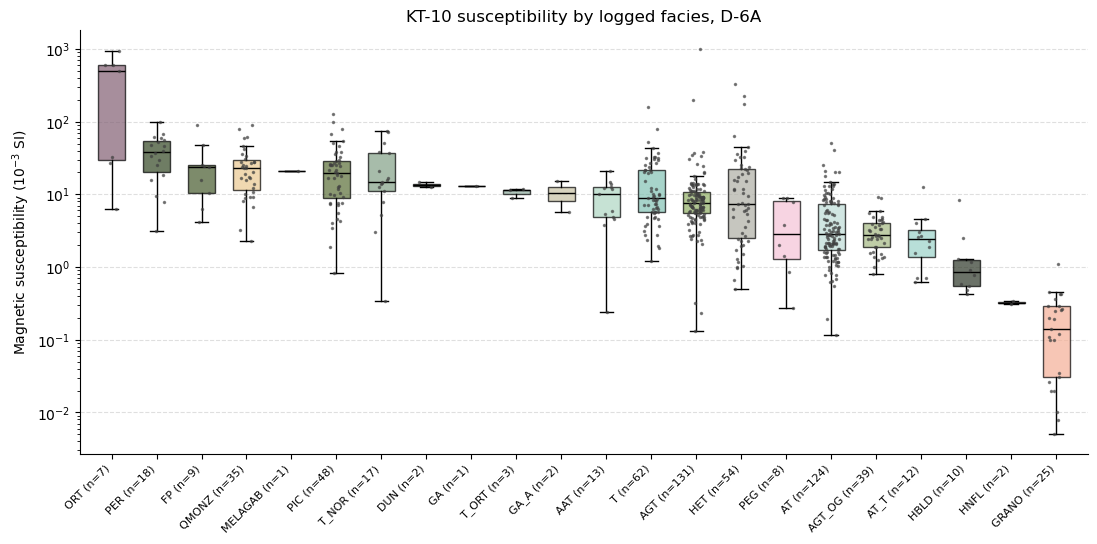

In [5]:
# Facies palette, shared with the lithologic column.
style_df = pd.read_csv(log_dir / 'D_6A_style.csv')
facies_colors = {
    row['facies']: (row['R'] / 255, row['G'] / 255, row['B'] / 255)
    for _, row in style_df.iterrows()
}

# Facies with only one or two measurements are shown, but the box is not
# meaningful for them — they are effectively plotted as points alone.
order = facies_summary.index.tolist()
groups = [susc.loc[susc['FACIES'] == f, 'susceptibility'].values for f in order]

fig, ax = plt.subplots(figsize=(13, 5.5))
boxes = ax.boxplot(
    groups, positions=np.arange(len(order)), widths=0.6,
    showfliers=False, patch_artist=True, medianprops={'color': 'k'},
)
for patch, facies in zip(boxes['boxes'], order):
    patch.set_facecolor(facies_colors.get(facies, '0.7'))
    patch.set_alpha(0.7)

rng = np.random.default_rng(4)
for i, values in enumerate(groups):
    jitter = rng.uniform(-0.18, 0.18, size=len(values))
    ax.plot(i + jitter, values, '.', markersize=3, color='0.25', alpha=0.6, zorder=3)

ax.set_yscale('log')
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(
    [f"{f} (n={facies_summary.loc[f, 'n']})" for f in order],
    fontsize=8, rotation=45, ha='right',
)
ax.set_xlim(-0.7, len(order) - 0.3)
ax.set_ylabel('Magnetic susceptibility (10$^{-3}$ SI)')
ax.set_title('KT-10 susceptibility by logged facies, D-6A')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

plt.show()